# Exploratory Data Analysis (EDA)

---
## 1. Setup & Data Loading

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

# Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Figure size defaults
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

✓ Libraries loaded successfully


In [2]:
# Load the dataset
df = pd.read_csv('Access_to_Care_Dataset.csv')

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset loaded: 26,208 rows × 25 columns
Memory usage: 19.3 MB


---
## 2. Data Inspection

In [3]:
df.head()

,TOPIC,SUBTOPIC,SUBTOPIC_ID,TAXONOMY,TAXONOMY_ID,CLASSIFICATION,CLASSIFICATION_ID,GROUP,GROUP_ID,GROUP_ORDER,SUBGROUP,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL,NESTING_LABEL_ID,ESTIMATE_TYPE,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI,FLAG,FOOTNOTE_ID_LIST
0,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2019,NaN,1.7,NaN,1.5,1.9,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
1,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2020,NaN,1.5,NaN,1.3,1.6,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
2,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2021,NaN,1.5,NaN,1.4,1.7,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
3,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2022,NaN,1.6,NaN,1.5,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"
4,Angina/angina pectoris,NaN,NaN,Cardiovascular diseases,60,Total,0,Total,1,1,18 years and older,1,1,NaN,NaN,"Percent of population, crude",1,2023,NaN,1.6,NaN,1.4,1.8,NaN,"NT_NHISA00,NT_NHISA999,FN_NHISA18,SC_NHISA00"


In [4]:
print("=" * 80)
print("Data Types and Missing Values")
print("=" * 80)

info_df = pd.DataFrame({
    'Column': df.columns,
    'Type': df.dtypes.values,
    'Non-Null': df.count().values,
    'Null': df.isnull().sum().values,
    'Null %': (df.isnull().sum() / len(df) * 100).round(2).values,
    'Unique': [df[col].nunique() for col in df.columns]
})

print(info_df.to_string(index=False))

Data Types and Missing Values
           Column    Type  Non-Null  Null  Null %  Unique
            TOPIC  object     26208     0    0.00      54
         SUBTOPIC  object      1404 24804   94.64       3
      SUBTOPIC_ID float64      1404 24804   94.64       3
         TAXONOMY  object     26208     0    0.00      19
      TAXONOMY_ID   int64     26208     0    0.00      19
   CLASSIFICATION  object     26208     0    0.00       4
CLASSIFICATION_ID   int64     26208     0    0.00       4
            GROUP  object     26208     0    0.00      21
         GROUP_ID   int64     26208     0    0.00      21
      GROUP_ORDER   int64     26208     0    0.00      21
         SUBGROUP  object     26208     0    0.00      75
      SUBGROUP_ID   int64     26208     0    0.00      78
   SUBGROUP_ORDER   int64     26208     0    0.00      78
    NESTING_LABEL  object      2016 24192   92.31       2
 NESTING_LABEL_ID float64      2016 24192   92.31       2
    ESTIMATE_TYPE  object     26208     0 

In [5]:
# Statistical summary of numerical columns
df.describe()

,SUBTOPIC_ID,TAXONOMY_ID,CLASSIFICATION_ID,GROUP_ID,GROUP_ORDER,SUBGROUP_ID,SUBGROUP_ORDER,NESTING_LABEL_ID,ESTIMATE_TYPE_ID,TIME_PERIOD,TIME_PERIOD_ID,ESTIMATE,STANDARD_ERROR,ESTIMATE_LCI,ESTIMATE_UCI
count,1404.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,26208.000000,2016.000000,26208.0,26208.000000,0.0,23839.000000,0.0,23633.000000,23633.000000
mean,2.000000,134.732143,1.769231,11.820513,11.820513,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,21.884232,NaN,20.667863,23.601011
std,0.816788,68.449798,0.890466,5.887395,5.887395,22.515239,22.515239,5.001241,0.0,1.707858,NaN,23.938021,NaN,23.556541,24.360457
min,1.000000,10.000000,0.000000,1.000000,1.000000,1.000000,1.000000,10.000000,1.0,2019.000000,NaN,0.000000,NaN,0.000000,0.000000
25%,1.000000,85.000000,1.000000,7.000000,7.000000,20.000000,20.000000,10.000000,1.0,2020.000000,NaN,5.600000,NaN,5.000000,6.700000
50%,2.000000,120.000000,1.000000,12.000000,12.000000,39.500000,39.500000,15.000000,1.0,2021.500000,NaN,12.600000,NaN,11.400000,14.300000
75%,3.000000,177.500000,3.000000,17.000000,17.000000,59.000000,59.000000,20.000000,1.0,2023.000000,NaN,26.700000,NaN,24.900000,29.500000
max,3.000000,270.000000,3.000000,21.000000,21.000000,78.000000,78.000000,20.000000,1.0,2024.000000,NaN,100.000000,NaN,100.000000,100.000000


---
## 3. Data Cleaning
Based on initial data inspection, the following columns were deemed essential or at least useful and kept in the cleaned dataframe:  
* TOPIC: Essential - Core filtering variable for all analysis  
* TAXONOMY: Useful - Organizational value for visualizations and reports  
* CLASSIFICATION: Essential - Prevent mixing overlaping populations and understand what level of detail you're looking at  
* GROUP: Very Useful - Understand relationships between subgroups, comparison organization  
* SUBGROUP: Essential - Specifies exactly which population is being measured  
* TIME_PERIOD: Essential - Enables temporal analysis  
* ESTIMATE: Essential - Target variable  
* ESTIMATE_LCI: Essential - For statistical rigor, determines if differences are meaningful or just noise  
* ESTIMATE_UCI: Essential - For statistical rigor, determines if differences are meaningful or just noise   
  
The other 16 were removed. These included empty or single-unique-value columns, redundant ID columns, display sorting columns, and sparse data columns.





In [6]:
# Keep only essential columns for analysis
essential_cols = [
    'TOPIC', 'TAXONOMY', 'CLASSIFICATION', 'GROUP', 'SUBGROUP',
    'TIME_PERIOD', 'ESTIMATE', 'ESTIMATE_LCI', 'ESTIMATE_UCI'
]
df = df[essential_cols]
print(f"Kept {len(essential_cols)} essential columns for analysis")

Kept 9 essential columns for analysis


ESTIMATE is the target variable, i.e. it is the most important piece of information. Therefore, rows that are missing this value are eliminated. This reduces the dataset by 9%, which is acceptable. The remaining data is a sufficient quantity for analysis.

In [7]:
# Remove rows where ESTIMATE is missing
before_count = len(df)
df = df.dropna(subset=['ESTIMATE'])
removed = before_count - len(df)
print(f"Removed {removed:,} rows with missing ESTIMATE values ({removed/before_count*100:.1f}%)")

Removed 2,369 rows with missing ESTIMATE values (9.0%)


Data type optimization was performed to save memory.
*   int64->int16: saves 75% memory, and is more than sufficient to store year
*   float64->float32: saves 50% memory, and is more than sufficient to store data that is only reported to 1 decimal place



In [8]:
# Data type optimization
df['TIME_PERIOD'] = df['TIME_PERIOD'].astype('int16')
df['ESTIMATE'] = df['ESTIMATE'].astype('float32')
df['ESTIMATE_LCI'] = df['ESTIMATE_LCI'].astype('float32')
df['ESTIMATE_UCI'] = df['ESTIMATE_UCI'].astype('float32')

In [9]:
# Check for duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    print(f"Found {duplicates} duplicate rows")
    df = df.drop_duplicates()
    print(f"Removed duplicates")
else:
    print("No duplicate rows found")

No duplicate rows found


In [10]:
# Access barriers only
access_topics = [
    'Delayed getting medical care due to cost among adults',
    'Did not get needed medical care due to cost',
    'Did not get needed mental health care due to cost',
    'Did not take medication as prescribed to save money',
    # 'Has a usual place of care among adults'
]
df = df[df['TOPIC'].isin(access_topics)].copy()

In [11]:
print("\n" + "=" * 80)
print(f"FINAL CLEANED DATASET: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")
print("=" * 80)


FINAL CLEANED DATASET: 1,807 rows × 9 columns
Memory usage: 0.7 MB


In [12]:
df.head()

,TOPIC,TAXONOMY,CLASSIFICATION,GROUP,SUBGROUP,TIME_PERIOD,ESTIMATE,ESTIMATE_LCI,ESTIMATE_UCI
9360,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2019,9.1,8.6,9.5
9361,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2020,7.5,7.1,8.0
9362,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2021,7.1,6.8,7.5
9363,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2022,7.0,6.6,7.4
9364,Delayed getting medical care due to cost among...,Healthcare access and quality,Total,Total,18 years and older,2023,7.2,6.8,7.6


---
## 3. Access Barriers - Comparative Analysis

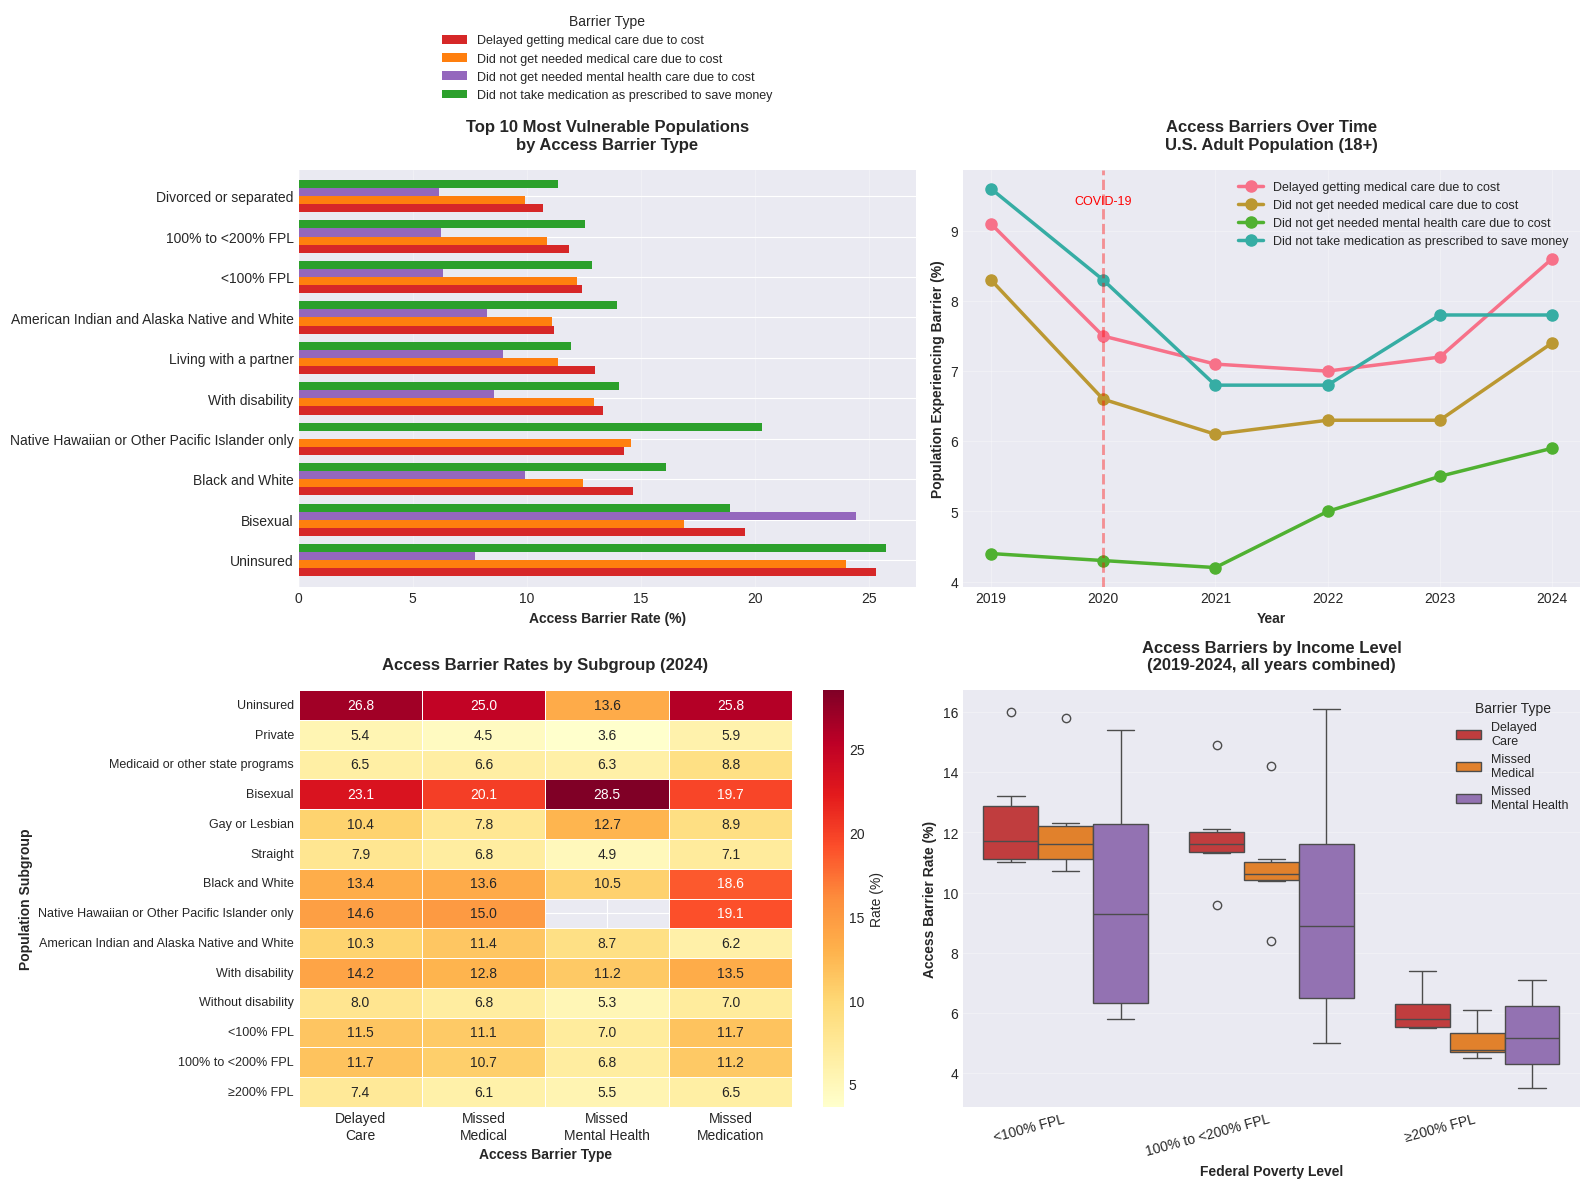

In [13]:
# ----------------------------------------------------------------------------
# Plot 1: Grouped Bar Chart - Top 10 Vulnerable Populations
# ----------------------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Calculate average rates by subgroup for each barrier
vulnerable_data = []
for topic in access_topics:
    topic_avg = df[df['TOPIC'] == topic].groupby('SUBGROUP')['ESTIMATE'].mean()
    topic_name = topic.replace(' among adults', '')

    for subgroup, rate in topic_avg.items():
        vulnerable_data.append({
            'Barrier': topic_name,
            'Subgroup': subgroup,
            'Rate': rate
        })

df_vulnerable = pd.DataFrame(vulnerable_data)

# Get top 10 overall most vulnerable subgroups
top_10_subgroups = df_vulnerable.groupby('Subgroup')['Rate'].mean().nlargest(10).index

# Plot grouped bar chart
plot_data = df_vulnerable[df_vulnerable['Subgroup'].isin(top_10_subgroups)]
pivot_data = plot_data.pivot(index='Subgroup', columns='Barrier', values='Rate')
pivot_data = pivot_data.reindex(top_10_subgroups)  # Sort by overall vulnerability

pivot_data.plot(kind='barh', ax=axes[0, 0], width=0.8,
                color=['#d62728', '#ff7f0e', '#9467bd', '#2ca02c'])
axes[0, 0].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[0, 0].set_ylabel('')
axes[0, 0].set_title('Top 10 Most Vulnerable Populations\nby Access Barrier Type',
                     fontweight='bold', pad=15)
axes[0, 0].legend(title='Barrier Type', fontsize=9, loc='upper center', bbox_to_anchor=(0.5, 1.4))
axes[0, 0].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Plot 2: Time Series - Trends 2019-2024
# ----------------------------------------------------------------------------
# Use total population only (no demographic breakdowns)
trend_data = df[df['CLASSIFICATION'] == 'Total'].copy()

for topic in access_topics:
    topic_data = trend_data[trend_data['TOPIC'] == topic].groupby('TIME_PERIOD')['ESTIMATE'].mean()
    label = topic.replace(' among adults', '')
    axes[0, 1].plot(topic_data.index, topic_data.values, marker='o',
                   linewidth=2.5, markersize=8, label=label)

axes[0, 1].set_xlabel('Year', fontweight='bold')
axes[0, 1].set_ylabel('Population Experiencing Barrier (%)', fontweight='bold')
axes[0, 1].set_title('Access Barriers Over Time\nU.S. Adult Population (18+)',
                     fontweight='bold', pad=15)
axes[0, 1].legend(fontsize=9, loc='best')
axes[0, 1].grid(alpha=0.3)
axes[0, 1].axvline(x=2020, color='red', linestyle='--', alpha=0.4, linewidth=2)
axes[0, 1].text(2020, axes[0, 1].get_ylim()[1] * 0.95, 'COVID-19',
               color='red', fontsize=9, ha='center')

# ----------------------------------------------------------------------------
# Plot 3: Heatmap - Barriers × Key Subgroups
# ----------------------------------------------------------------------------
# Focus on 2024, socioeconomic + demographic subgroups
key_subgroups = [
    'Uninsured', 'Private', 'Medicaid or other state programs',
    'Bisexual', 'Gay or Lesbian', 'Straight',
    'Black and White', 'Native Hawaiian or Other Pacific Islander only', 'American Indian and Alaska Native and White',
    'With disability', 'Without disability',
    '<100% FPL', '100% to <200% FPL', '≥200% FPL'
]

heatmap_data = df[
    (df['SUBGROUP'].isin(key_subgroups)) &
    (df['TIME_PERIOD'] == 2024)
].pivot_table(
    index='SUBGROUP',
    columns='TOPIC',
    values='ESTIMATE',
    aggfunc='mean'
)

# Reorder to match key_subgroups order
heatmap_data = heatmap_data.reindex([s for s in key_subgroups if s in heatmap_data.index])

# Shorten column names
heatmap_data.columns = ['Delayed\nCare', 'Missed\nMedical', 'Missed\nMental Health', 'Missed\nMedication']

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
           linewidths=0.5, ax=axes[1, 0], cbar_kws={'label': 'Rate (%)'})
axes[1, 0].set_xlabel('Access Barrier Type', fontweight='bold')
axes[1, 0].set_ylabel('Population Subgroup', fontweight='bold')
axes[1, 0].set_title('Access Barrier Rates by Subgroup (2024)',
                    fontweight='bold', pad=15)
axes[1, 0].set_yticklabels(axes[1, 0].get_yticklabels(), rotation=0, fontsize=9)

# ----------------------------------------------------------------------------
# Plot 4: Boxplot - Barriers by Income Level (Single Demographic Dimension)
# ----------------------------------------------------------------------------
# Filter to poverty level subgroups only (mutually exclusive)
poverty_data = df[
    df['GROUP'] == 'Poverty level'
].copy()

# Create abbreviated topic labels
poverty_data['Barrier'] = poverty_data['TOPIC'].apply(
    lambda x: 'Delayed\nCare' if 'Delayed' in x
    else 'Missed\nMedical' if 'medical care' in x
    else 'Missed\nMental Health'
)

sns.boxplot(data=poverty_data, x='SUBGROUP', y='ESTIMATE', hue='Barrier',
           ax=axes[1, 1], palette=['#d62728', '#ff7f0e', '#9467bd'])
axes[1, 1].set_xlabel('Federal Poverty Level', fontweight='bold')
axes[1, 1].set_ylabel('Access Barrier Rate (%)', fontweight='bold')
axes[1, 1].set_title('Access Barriers by Income Level\n(2019-2024, all years combined)',
                    fontweight='bold', pad=15)
axes[1, 1].legend(title='Barrier Type', fontsize=9, loc='upper right')
axes[1, 1].grid(axis='y', alpha=0.3)

# Rotate x-axis labels for readability
plt.setp(axes[1, 1].get_xticklabels(), rotation=15, ha='right')

plt.tight_layout()
plt.show()

## 5. Disparities Snapshot: Race, Insurance, and Income

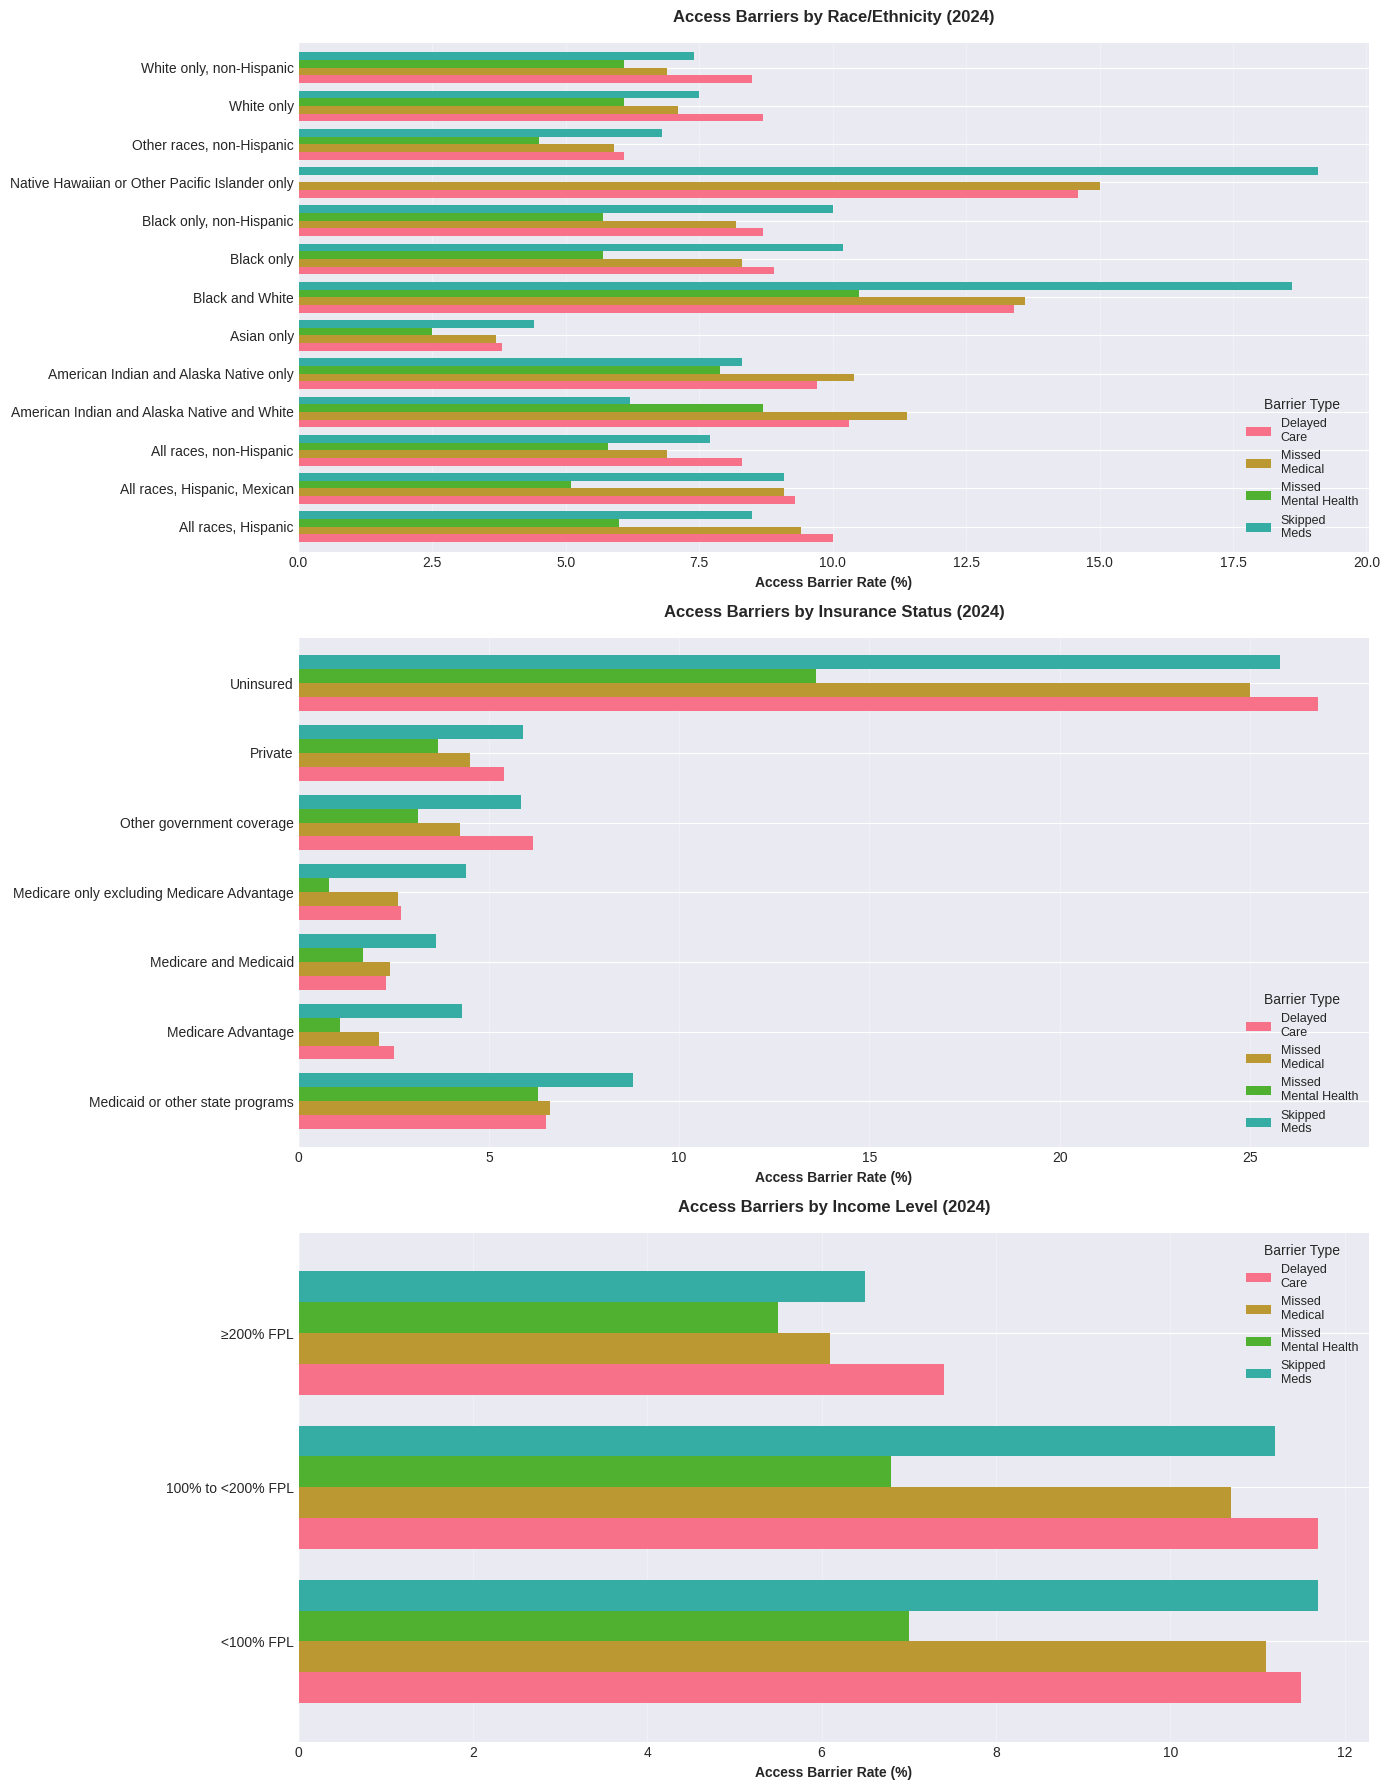

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(14, 18))

# ----------------------------------------------------------------------------
# Panel 1: RACE/ETHNICITY Disparities
# ----------------------------------------------------------------------------
race_data = df[
    (df['GROUP'].str.contains('Race', na=False)) &
    (df['TIME_PERIOD'] == 2024)
]

race_pivot = race_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
race_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                      'Missed\nMental Health', 'Skipped\nMeds']

race_pivot.plot(kind='barh', ax=axes[0], width=0.8)
axes[0].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[0].set_ylabel('')
axes[0].set_title('Access Barriers by Race/Ethnicity (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[0].legend(title='Barrier Type', loc='lower right', fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Panel 2: INSURANCE STATUS Disparities
# ----------------------------------------------------------------------------
insurance_data = df[
    (df['GROUP'].str.contains('insurance', case=False, na=False)) &
    (df['TIME_PERIOD'] == 2024)
]

insurance_pivot = insurance_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
insurance_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                           'Missed\nMental Health', 'Skipped\nMeds']

insurance_pivot.plot(kind='barh', ax=axes[1], width=0.8)
axes[1].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[1].set_ylabel('')
axes[1].set_title('Access Barriers by Insurance Status (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[1].legend(title='Barrier Type', loc='lower right', fontsize=9)
axes[1].grid(axis='x', alpha=0.3)

# ----------------------------------------------------------------------------
# Panel 3: INCOME LEVEL Disparities
# ----------------------------------------------------------------------------
income_data = df[
    (df['GROUP'] == 'Poverty level') &
    (df['TIME_PERIOD'] == 2024)
]

income_pivot = income_data.pivot_table(
    index='SUBGROUP', columns='TOPIC', values='ESTIMATE', aggfunc='mean'
)
income_pivot.columns = ['Delayed\nCare', 'Missed\nMedical',
                        'Missed\nMental Health', 'Skipped\nMeds']

# Order by poverty level
poverty_order = ['<100% FPL', '100% to <200% FPL', '≥200% FPL']
income_pivot = income_pivot.reindex(poverty_order)

income_pivot.plot(kind='barh', ax=axes[2], width=0.8)
axes[2].set_xlabel('Access Barrier Rate (%)', fontweight='bold')
axes[2].set_ylabel('')
axes[2].set_title('Access Barriers by Income Level (2024)',
                  fontweight='bold', fontsize=12, pad=15)
axes[2].legend(title='Barrier Type', loc='upper right', fontsize=9)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

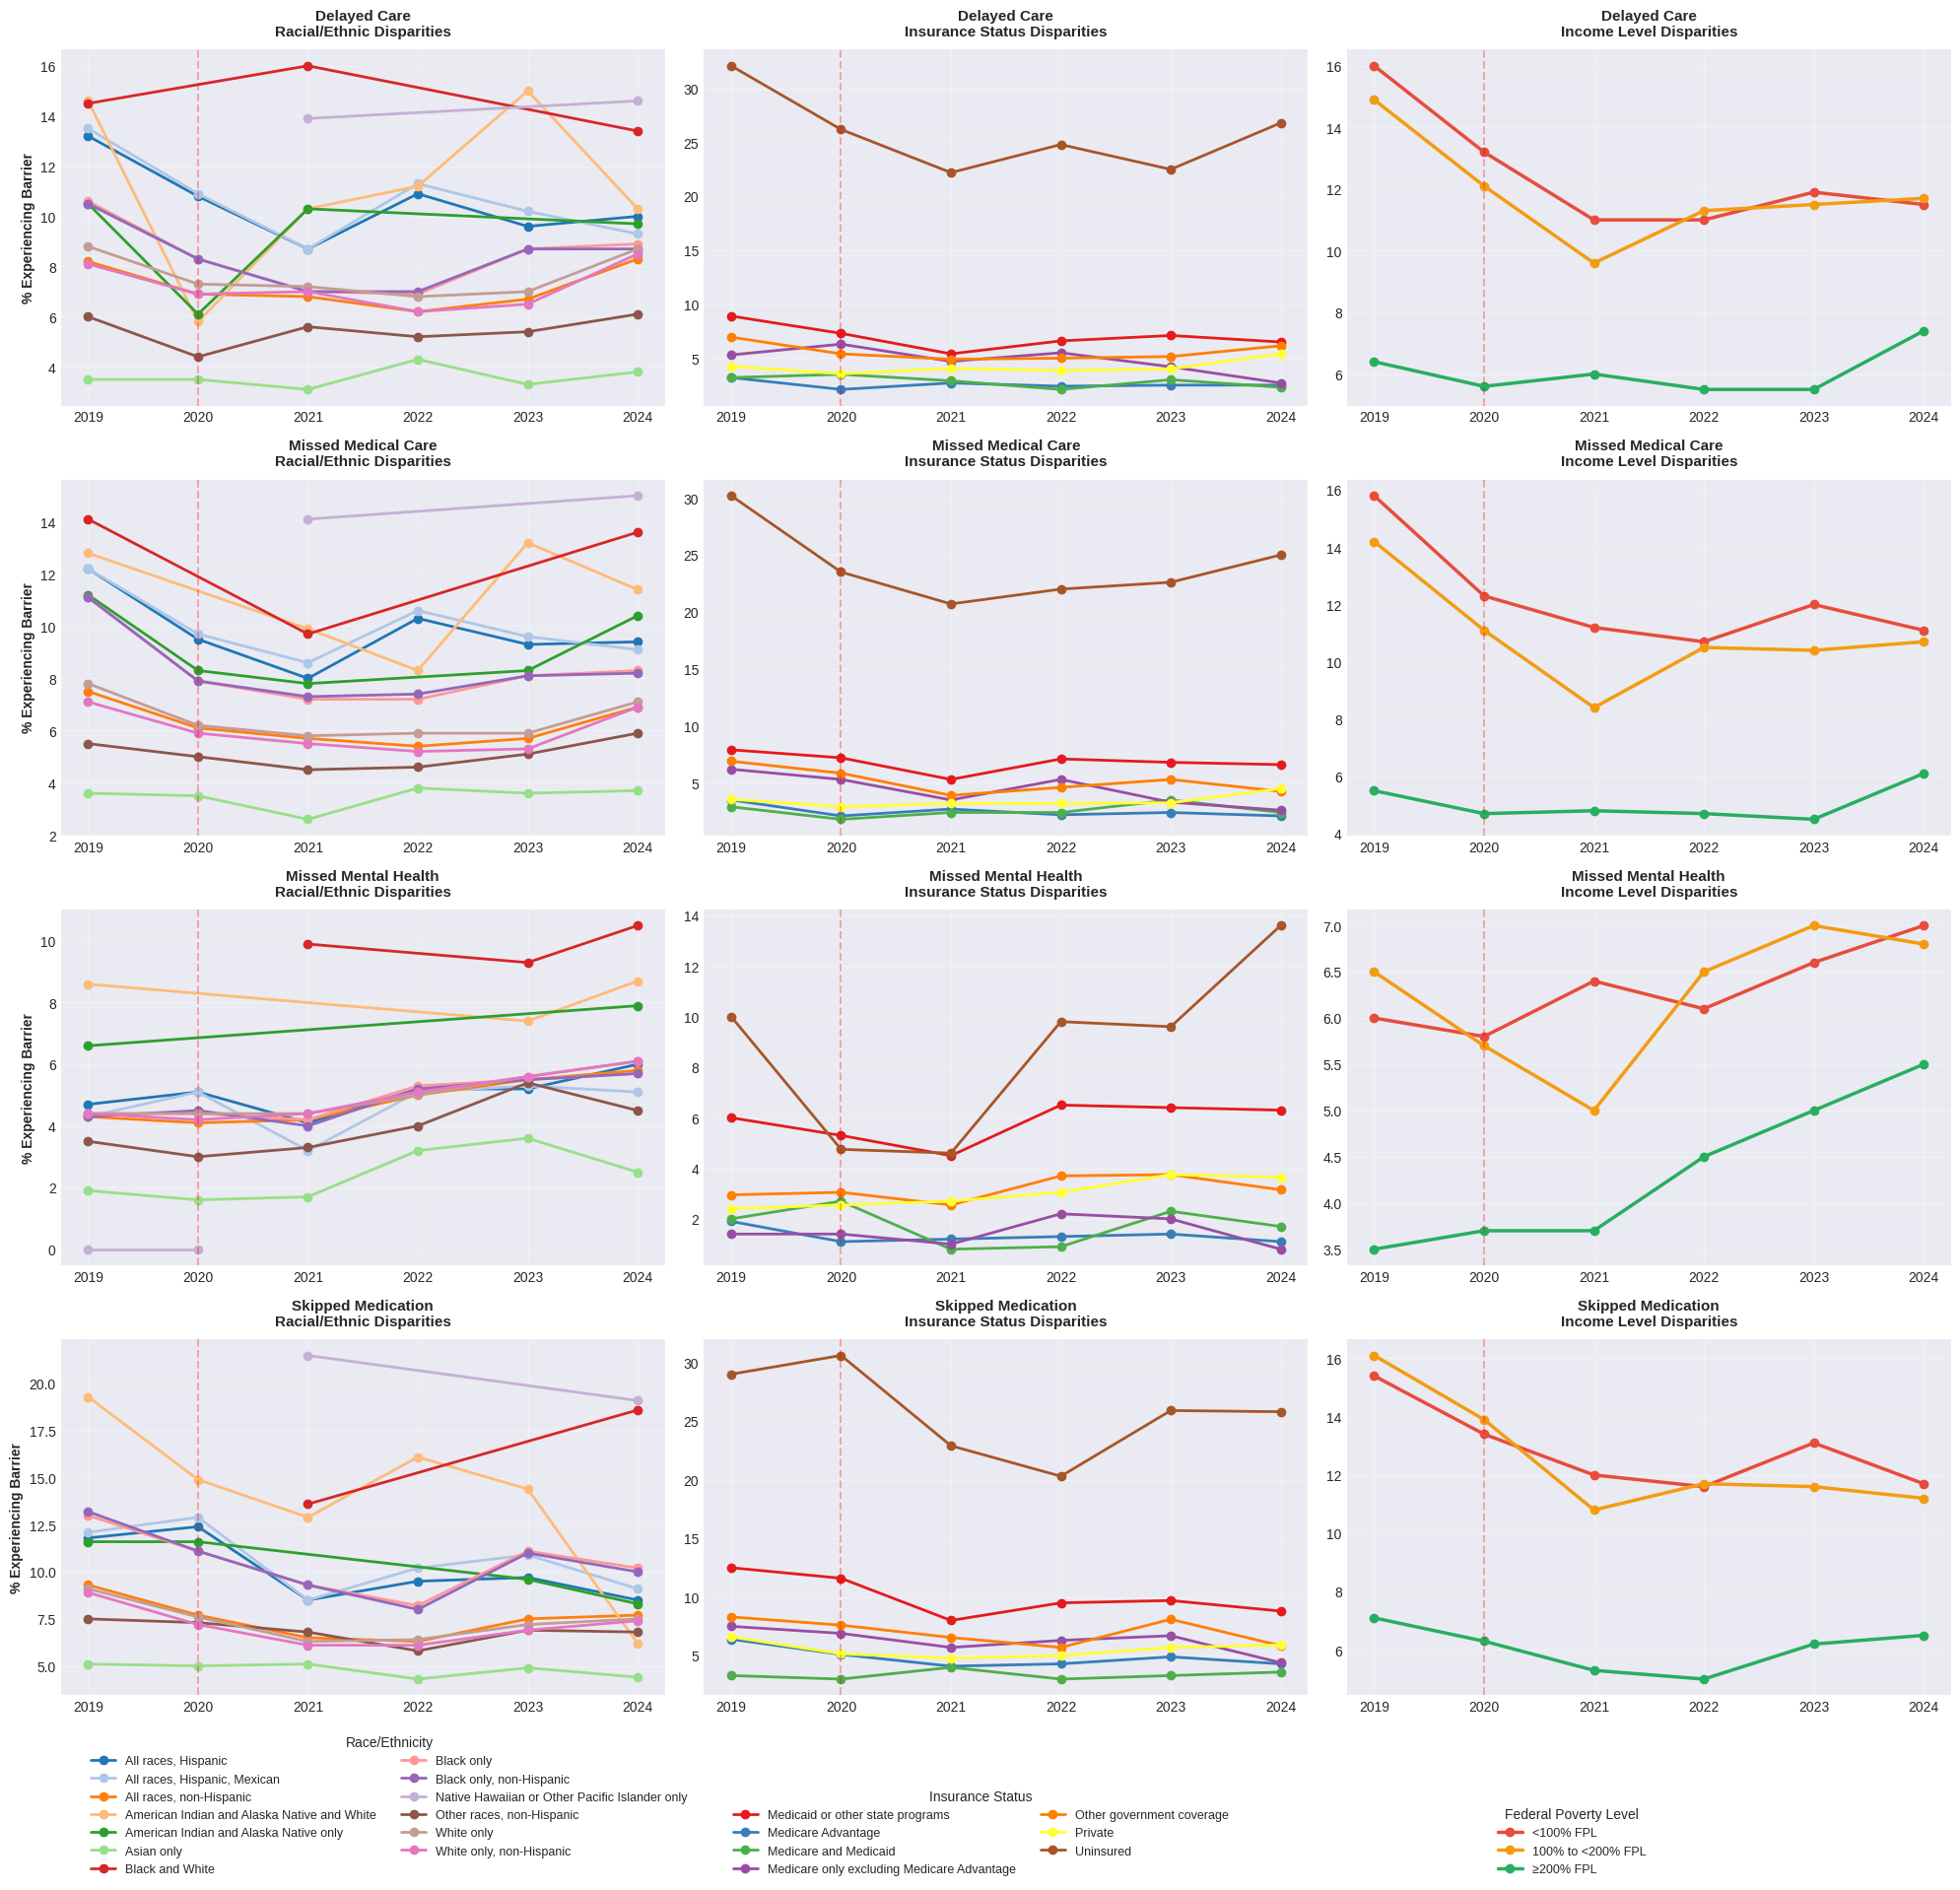

In [15]:
# Barrier names (shortened for titles)
barrier_names = {
    'Delayed getting medical care due to cost among adults': 'Delayed Care',
    'Did not get needed medical care due to cost': 'Missed Medical Care',
    'Did not get needed mental health care due to cost': 'Missed Mental Health',
    'Did not take medication as prescribed to save money': 'Skipped Medication'
}

titles = ['Racial/Ethnic Disparities', 'Insurance Status Disparities', 'Income Level Disparities']

# Pre-define consistent colors
all_race_subs = sorted(df[df['GROUP'].str.contains('Race', na=False)]['SUBGROUP'].unique())
race_color_map = {sub: plt.cm.tab20(i) for i, sub in enumerate(all_race_subs)}

all_ins_subs = sorted(df[df['GROUP'].str.contains('insurance', case=False, na=False)]['SUBGROUP'].unique())
ins_color_map = {sub: plt.cm.Set1(i) for i, sub in enumerate(all_ins_subs)}

poverty_levels = ['<100% FPL', '100% to <200% FPL', '≥200% FPL']
colors_income = ['#e74c3c', '#f39c12', '#27ae60']

fig, axes = plt.subplots(4, 3, figsize=(20, 20))

# Separate handle/label storage for each column
race_handles, ins_handles, inc_handles = {}, {}, {}

for b_idx, (topic, short_name) in enumerate(barrier_names.items()):

    # --- Column 1: RACE ---
    race_data = df[(df['GROUP'].str.contains('Race', na=False)) & (df['TOPIC'] == topic)]
    for race in all_race_subs:
        subset = race_data[race_data['SUBGROUP'] == race].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 0].plot(subset.index, subset.values, marker='o',
                                       color=race_color_map[race], label=race, linewidth=2)
            # Only capture the handle once for the legend
            if race not in race_handles:
                race_handles[race] = line[0]

    # --- Column 2: INSURANCE ---
    ins_data = df[(df['GROUP'].str.contains('insurance', case=False, na=False)) & (df['TOPIC'] == topic)]
    for ins in all_ins_subs:
        subset = ins_data[ins_data['SUBGROUP'] == ins].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 1].plot(subset.index, subset.values, marker='o',
                                       color=ins_color_map[ins], label=ins, linewidth=2)
            if ins not in ins_handles:
                ins_handles[ins] = line[0]

    # --- Column 3: INCOME ---
    inc_data = df[(df['GROUP'] == 'Poverty level') & (df['TOPIC'] == topic)]
    for i, pov in enumerate(poverty_levels):
        subset = inc_data[inc_data['SUBGROUP'] == pov].groupby('TIME_PERIOD')['ESTIMATE'].mean()
        if not subset.empty:
            line = axes[b_idx, 2].plot(subset.index, subset.values, marker='o',
                                       color=colors_income[i], label=pov, linewidth=2.5)
            if pov not in inc_handles:
                inc_handles[pov] = line[0]

    # Formatting
    axes[b_idx, 0].set_ylabel('% Experiencing Barrier', fontweight='bold')
    for c_idx in range(3):
        axes[b_idx, c_idx].grid(alpha=0.3)
        axes[b_idx, c_idx].axvline(x=2020, color='red', linestyle='--', alpha=0.3)
        axes[b_idx, c_idx].set_title(f'{short_name}\n{titles[c_idx]}',
                                      fontweight='bold', fontsize=11, pad=10)

# 2. Clean legends
fig.legend(race_handles.values(), race_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.2, 0.0), ncol=2, title='Race/Ethnicity', fontsize=9)

fig.legend(ins_handles.values(), ins_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, title='Insurance Status', fontsize=9)

fig.legend(inc_handles.values(), inc_handles.keys(),
           loc='lower center', bbox_to_anchor=(0.8, 0.0), ncol=1, title='Federal Poverty Level', fontsize=9)

plt.tight_layout(rect=[0, 0.08, 1, 0.96])
plt.show()


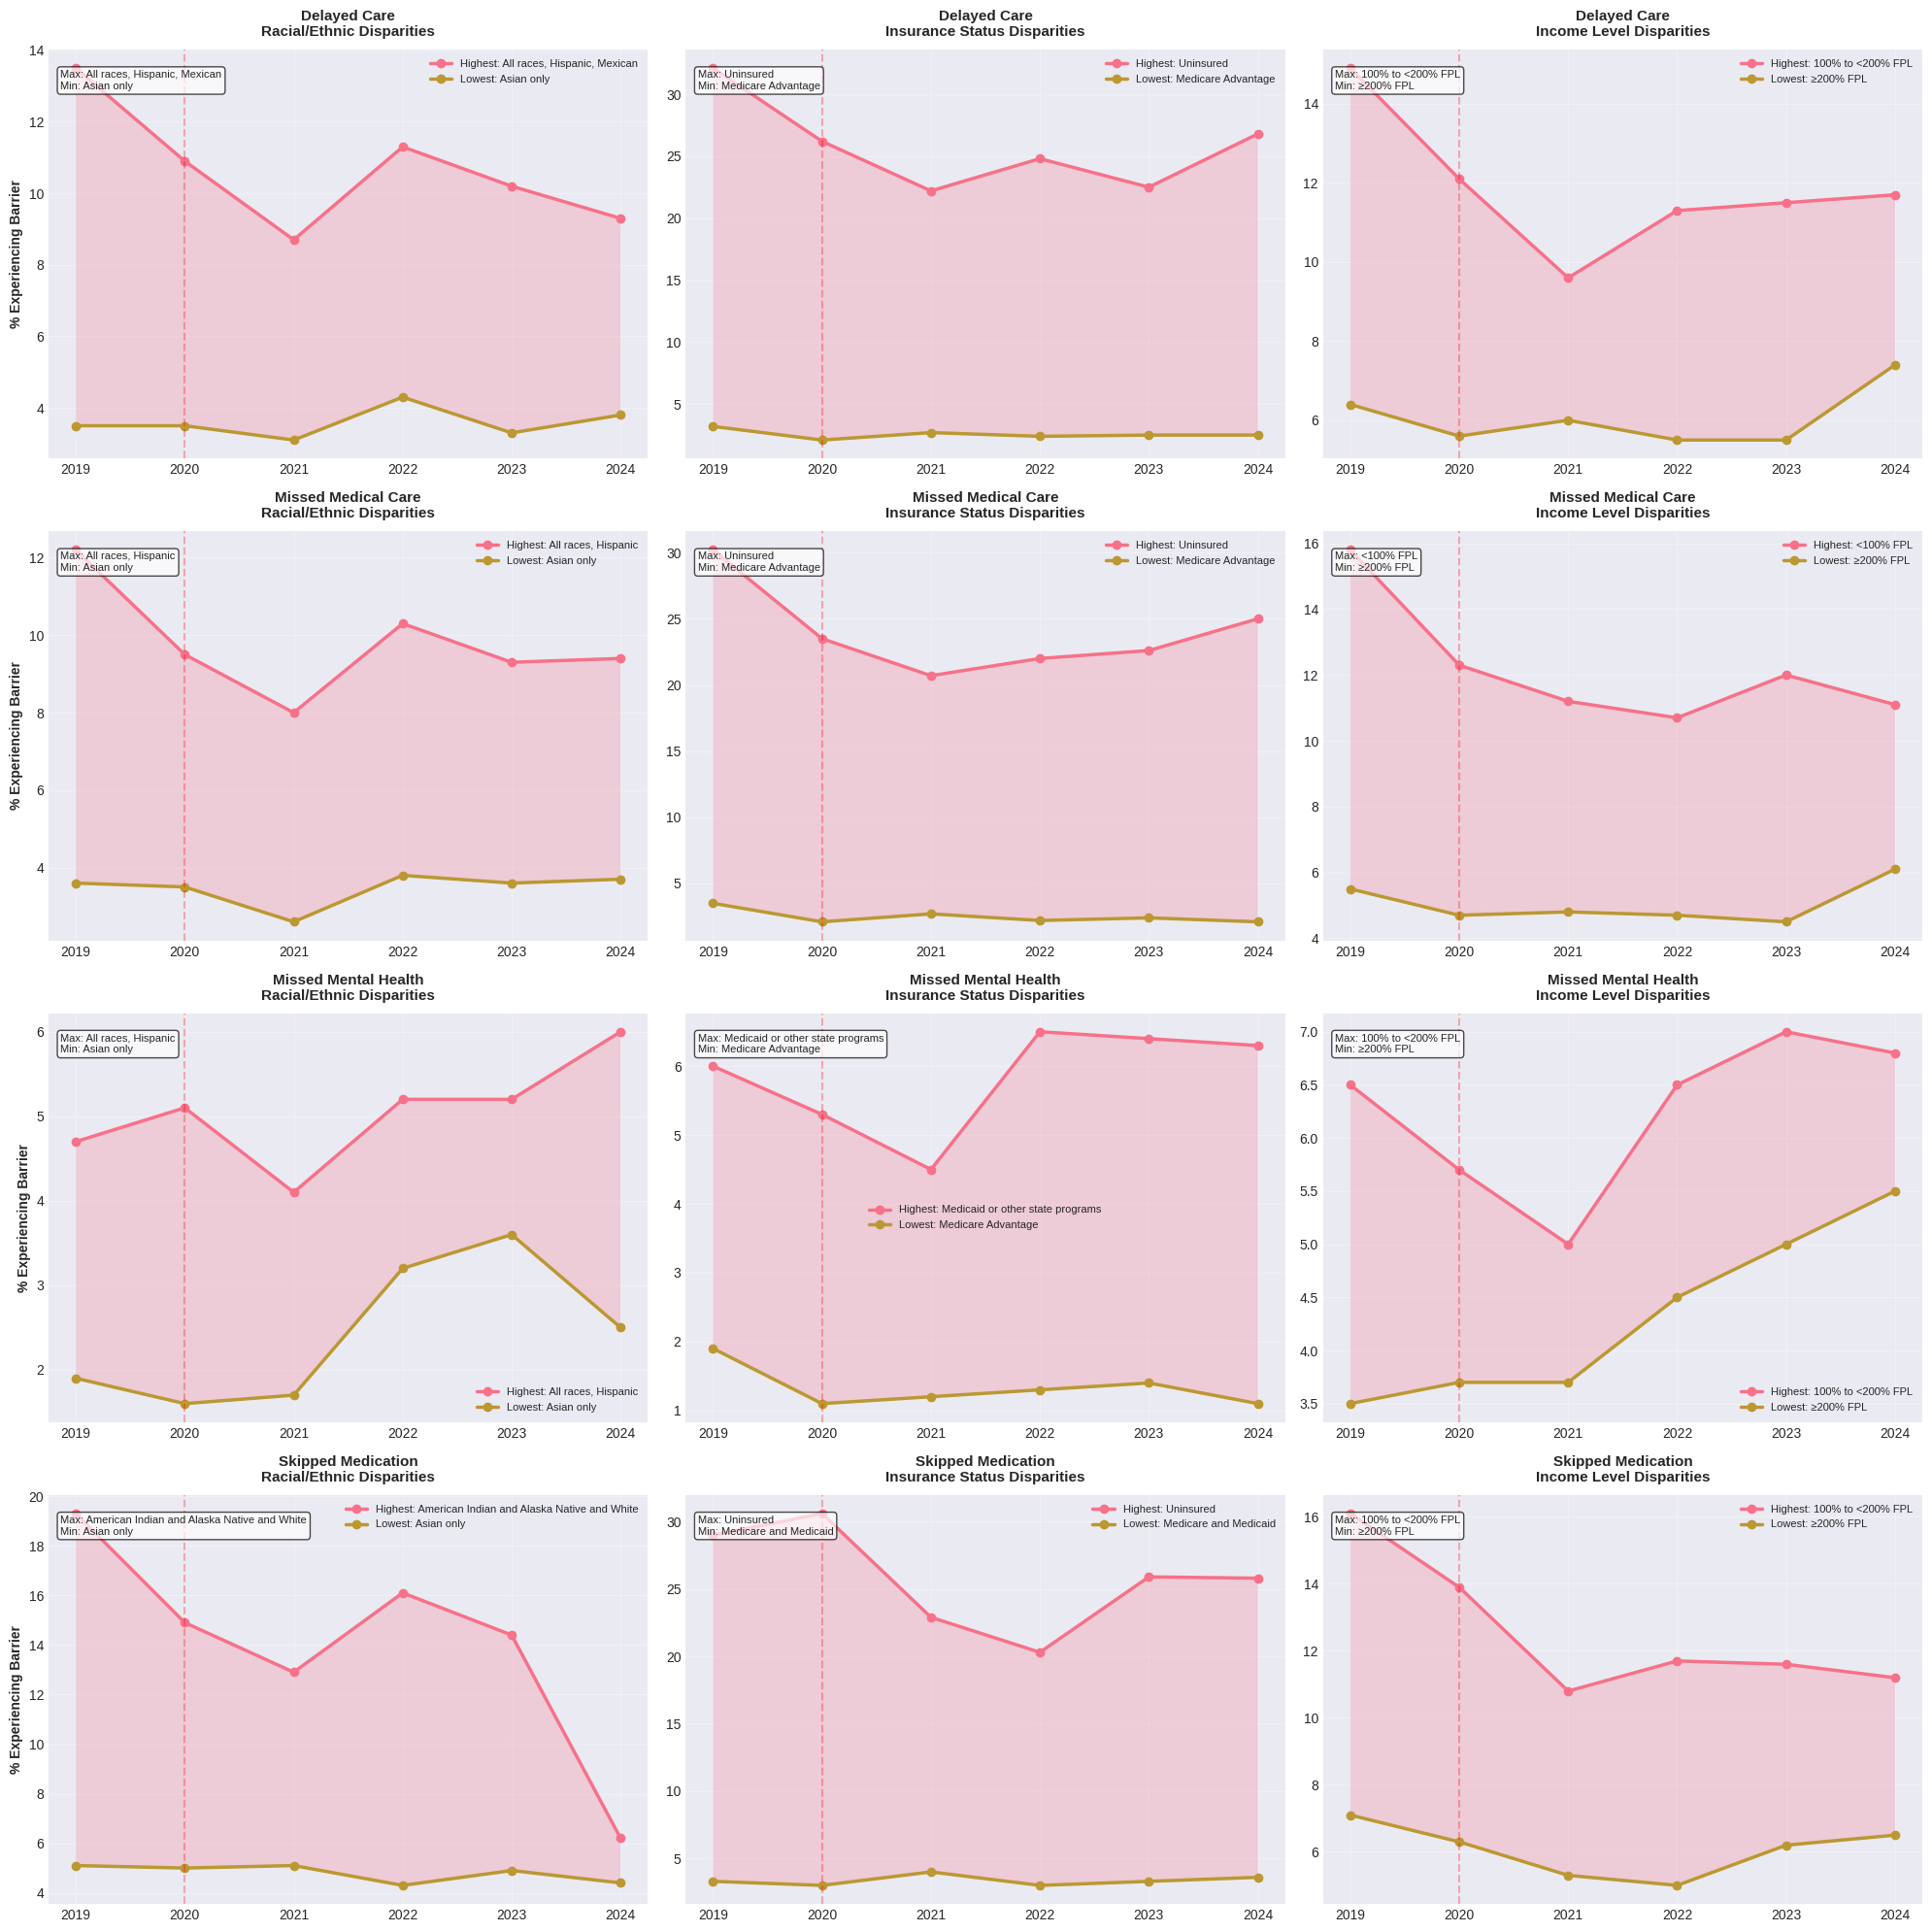

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Barrier names (shortened for titles)
barrier_names = {
    'Delayed getting medical care due to cost among adults': 'Delayed Care',
    'Did not get needed medical care due to cost': 'Missed Medical Care',
    'Did not get needed mental health care due to cost': 'Missed Mental Health',
    'Did not take medication as prescribed to save money': 'Skipped Medication'
}

titles = [
    'Racial/Ethnic Disparities',
    'Insurance Status Disparities',
    'Income Level Disparities'
]


fig, axes = plt.subplots(4, 3, figsize=(20, 20))


# ----------------------------------------------------
# Helper: Keep only subgroups with full year coverage
# ----------------------------------------------------
def filter_complete_subgroups(data, years):

    counts = data.groupby('SUBGROUP')['TIME_PERIOD'].nunique()

    valid_subs = counts[counts == len(years)].index

    return data[data['SUBGROUP'].isin(valid_subs)]


# ----------------------------------------------------
# Helper: Get yearly max/min subgroups
# ----------------------------------------------------
def get_extreme_subgroups(data, years):

    max_groups = []
    min_groups = []

    for y in years:

        yearly = data[data['TIME_PERIOD'] == y]

        means = yearly.groupby('SUBGROUP')['ESTIMATE'].mean()

        max_groups.append(means.idxmax())
        min_groups.append(means.idxmin())

    return list(set(max_groups)), list(set(min_groups))


# ----------------------------------------------------
# Main Plot Loop
# ----------------------------------------------------
for b_idx, (topic, short_name) in enumerate(barrier_names.items()):

    for c_idx, group_type in enumerate(['race', 'insurance', 'income']):

        # ----------------------------
        # Subset by group
        # ----------------------------
        if group_type == 'race':

            data = df[
                (df['GROUP'].str.contains('Race', na=False)) &
                (df['TOPIC'] == topic)
            ]

        elif group_type == 'insurance':

            data = df[
                (df['GROUP'].str.contains('insurance', case=False, na=False)) &
                (df['TOPIC'] == topic)
            ]

        else:  # income

            data = df[
                (df['GROUP'] == 'Poverty level') &
                (df['TOPIC'] == topic)
            ]


        if data.empty:
            continue


        ax = axes[b_idx, c_idx]

        years = sorted(data['TIME_PERIOD'].unique())


        # ----------------------------
        # Keep only full-coverage subgroups
        # ----------------------------
        data = filter_complete_subgroups(data, years)


        if data.empty:
            continue


        # ----------------------------
        # Find yearly extremes
        # ----------------------------
        max_subs, min_subs = get_extreme_subgroups(data, years)


        # Pick most frequent max/min
        max_sub = pd.Series(max_subs).mode()[0]
        min_sub = pd.Series(min_subs).mode()[0]


        # ----------------------------
        # Extract time series
        # ----------------------------
        max_series = (
            data[data['SUBGROUP'] == max_sub]
            .groupby('TIME_PERIOD')['ESTIMATE']
            .mean()
            .reindex(years)
        )

        min_series = (
            data[data['SUBGROUP'] == min_sub]
            .groupby('TIME_PERIOD')['ESTIMATE']
            .mean()
            .reindex(years)
        )


        # ----------------------------
        # Plot
        # ----------------------------
        ax.plot(
            years, max_series,
            marker='o',
            linewidth=2.5,
            label=f'Highest: {max_sub}'
        )

        ax.plot(
            years, min_series,
            marker='o',
            linewidth=2.5,
            label=f'Lowest: {min_sub}'
        )


        # Shade gap
        ax.fill_between(
            years,
            min_series,
            max_series,
            alpha=0.25
        )


        # ----------------------------
        # Labels
        # ----------------------------
        ax.legend(fontsize=8)

        ax.text(
            0.02, 0.95,
            f'Max: {max_sub}\nMin: {min_sub}',
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7)
        )


        # ----------------------------
        # Formatting
        # ----------------------------
        ax.grid(alpha=0.3)
        ax.axvline(x=2020, color='red', linestyle='--', alpha=0.3)

        ax.set_title(
            f'{short_name}\n{titles[c_idx]}',
            fontweight='bold',
            fontsize=11,
            pad=10
        )


    axes[b_idx, 0].set_ylabel(
        '% Experiencing Barrier',
        fontweight='bold'
    )


plt.tight_layout()
plt.show()
